Chart saved successfully as custom_portfolio_projection.png


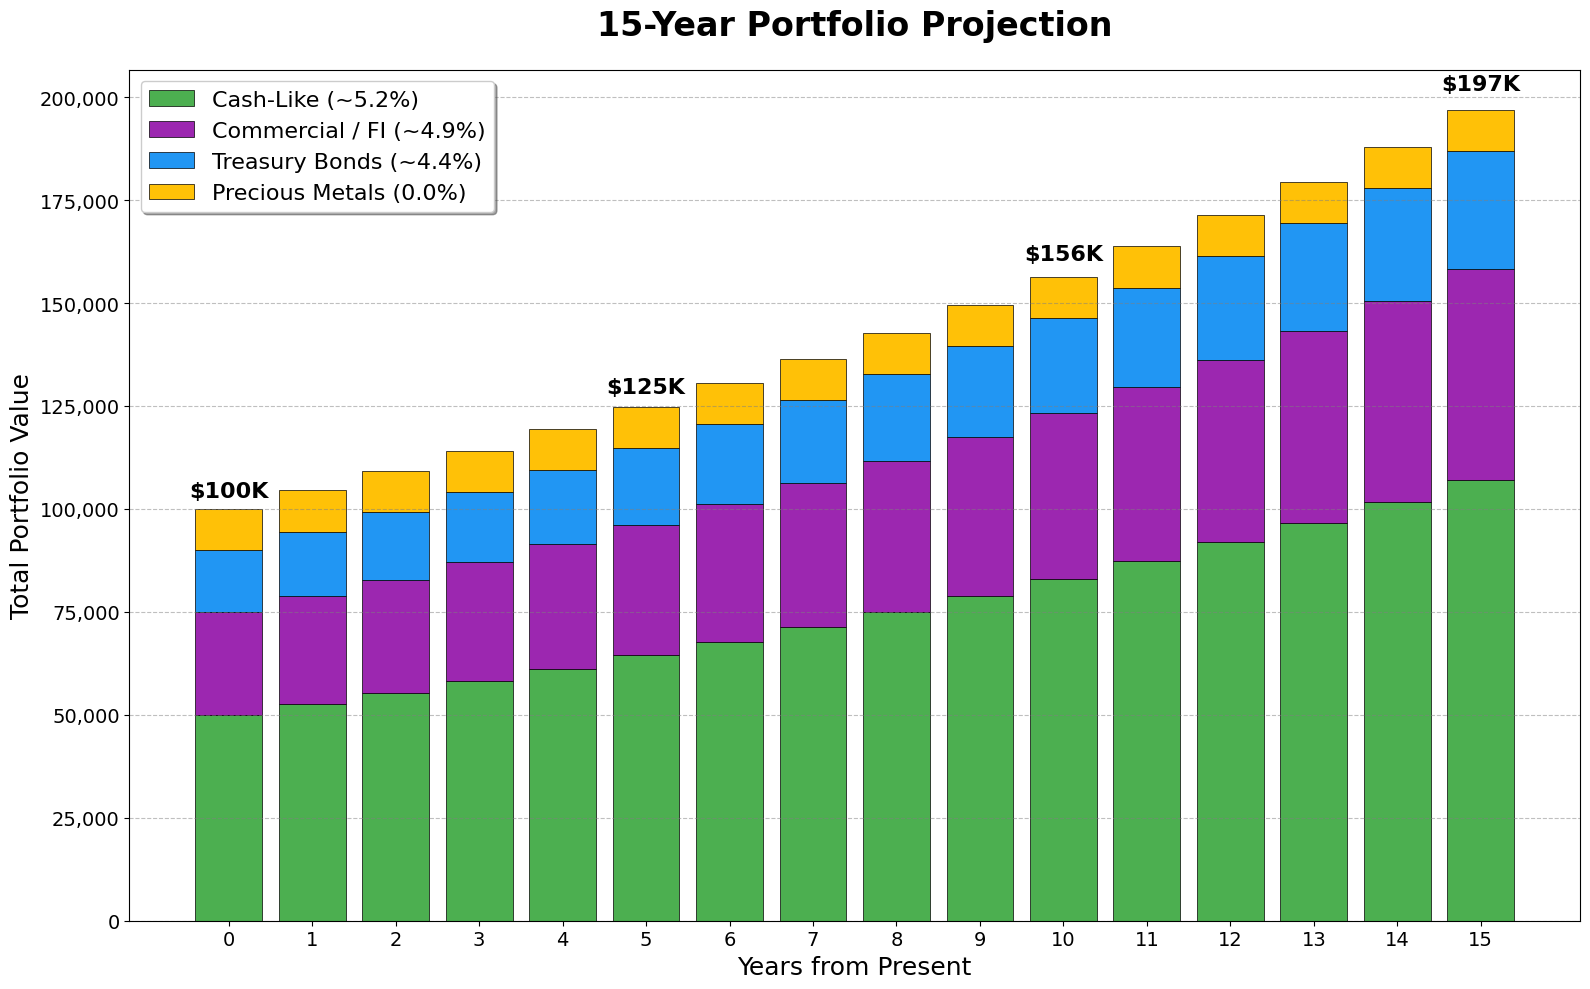

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. CONFIGURE YOUR PORTFOLIO SETTINGS HERE
# ==========================================

# Enter the initial values for each asset class
initial_cash = 50000       # e.g., Money market, ultra-short bonds
initial_commercial = 25000 # e.g., Corporate bonds, aggregate fixed income
initial_treasury = 15000   # e.g., Long-duration or direct treasuries
initial_metals = 10000     # e.g., Gold, silver

# Enter the expected annual yield for each asset class (as a decimal)
yield_cash = 0.052         # 5.2%
yield_commercial = 0.049   # 4.9%
yield_treasury = 0.044     # 4.4%
yield_metals = 0.000       # 0.0%

# Set the projection timeframe
projection_years = 15

# ==========================================
# 2. CALCULATION & PLOTTING ENGINE
# ==========================================

years = np.arange(0, projection_years + 1)

# Calculate compound growth (assuming annual reinvestment)
cash_vals = np.array([initial_cash * ((1 + yield_cash) ** y) for y in years])
commercial_vals = np.array([initial_commercial * ((1 + yield_commercial) ** y) for y in years])
treasury_vals = np.array([initial_treasury * ((1 + yield_treasury) ** y) for y in years])
metals_vals = np.array([initial_metals * ((1 + yield_metals) ** y) for y in years])

# Setup for High-Resolution Plot
fig, ax = plt.subplots(figsize=(16, 10))
bottom = np.zeros(projection_years + 1)

# Stack 1: Cash-Like
ax.bar(years, cash_vals, label=f'Cash-Like (~{yield_cash*100:.1f}%)', color='#4CAF50', bottom=bottom, edgecolor='black', linewidth=0.5)
bottom += cash_vals

# Stack 2: Commercial / Fixed Income
ax.bar(years, commercial_vals, label=f'Commercial / FI (~{yield_commercial*100:.1f}%)', color='#9C27B0', bottom=bottom, edgecolor='black', linewidth=0.5)
bottom += commercial_vals

# Stack 3: Treasury Bonds
ax.bar(years, treasury_vals, label=f'Treasury Bonds (~{yield_treasury*100:.1f}%)', color='#2196F3', bottom=bottom, edgecolor='black', linewidth=0.5)
bottom += treasury_vals

# Stack 4: Precious Metals
ax.bar(years, metals_vals, label=f'Precious Metals ({yield_metals*100:.1f}%)', color='#FFC107', bottom=bottom, edgecolor='black', linewidth=0.5)

# Formatting
ax.set_title(f'{projection_years}-Year Portfolio Projection', fontsize=24, pad=25, fontweight='bold')
ax.set_xlabel('Years from Present', fontsize=18)
ax.set_ylabel('Total Portfolio Value', fontsize=18)
ax.set_xticks(years)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Legend and Grid
ax.legend(loc='upper left', fontsize=16, frameon=True, shadow=True)
ax.grid(axis='y', linestyle='--', alpha=0.5, color='gray')

# Dynamic label formatting function for the totals
def format_total(val):
    if val >= 1_000_000:
        return f'${val/1_000_000:.2f}M'
    elif val >= 1_000:
        return f'${val/1_000:.0f}K'
    return f'${val:.0f}'

# Dynamic interval for displaying total values on bars
label_interval = max(1, projection_years // 3)
display_years = list(range(0, projection_years + 1, label_interval))
if projection_years not in display_years:
    display_years.append(projection_years)

for y in display_years:
    total_val = cash_vals[y] + commercial_vals[y] + treasury_vals[y] + metals_vals[y]
    # Offset slightly for visual spacing based on total height
    offset = total_val * 0.02
    ax.text(y, total_val + offset, format_total(total_val), ha='center', va='bottom', fontsize=16, fontweight='bold')

plt.tight_layout()

# Save with 1200 DPI to guarantee high fidelity
filename = 'custom_portfolio_projection.png'
plt.savefig(filename, dpi=1200)
print(f"Chart saved successfully as {filename}")
